# Create Base Version of dataset 

Files kind:
- md_content : Markdown ocr with everything
- md_content_nohf : Markdown ocr without Header and Footer
- file_path : Address of PDF file
- layout_info : Bounding box of images and texts within a file
- layout_image : Bounding box of images and texts within a page

In [1]:
import os
import json
from datasets import Dataset, DatasetDict
from glob import glob

# Replace Base
old_base = "/home/parsa/panasonic"
new_base = "/home/parsa/panasonic"

# JSONL path
root_dir = "./ocr_output/category"

# Find all JSONLs
jsonl_files = glob(os.path.join(root_dir, '**/*.jsonl'), recursive=True)
print(f"[JSONL_FOUND] {len(jsonl_files)} jsonl files.")

/home/parsa/.conda/envs/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[JSONL_FOUND] 906 jsonl files.


In [2]:
all_records = []

for jsonl_file in jsonl_files:
    with open(jsonl_file, 'r') as f:
        for line in f:
            if line.strip():
                record = json.loads(line)
                for key in ['md_content_path', 'layout_info_path','md_content_nohf_path','layout_image_path', 'file_path']:
                    if key in record:
                        record[key] = record[key].replace(old_base, new_base)
                
                all_records.append(record)

print(f"Total records collected: {len(all_records)}")                        

Total records collected: 7525


In [3]:
all_records[0]

{'page_no': 0,
 'input_height': 2352,
 'input_width': 1652,
 'layout_info_path': '/home/parsa/panasonic/ocr_output/category/product_catalogs/pdf_file_7559/pdf_file_7559_page_0.json',
 'layout_image_path': '/home/parsa/panasonic/ocr_output/category/product_catalogs/pdf_file_7559/pdf_file_7559_page_0.jpg',
 'md_content_path': '/home/parsa/panasonic/ocr_output/category/product_catalogs/pdf_file_7559/pdf_file_7559_page_0.md',
 'filtered': True,
 'file_path': '/home/parsa/panasonic/pdf/category/product_catalogs/pdf_file_7559.pdf'}

In [4]:
for record in all_records:
    try:
        with open(record['md_content_path'], 'r') as md_file:
            record['md_content'] = md_file.read()
        if 'md_content_nohf_path' in record:
            with open(record['md_content_nohf_path'], 'r') as md_nhf_file:
                record['md_content_nhf'] = md_nhf_file.read()
    except Exception as e:
        print(record)
        print(f"Error {e}")

print(f"All files are updated with md_content.")
    

All files are updated with md_content.


{'page_no': 0,
 'input_height': 2212,
 'input_width': 1708,
 'layout_info_path': '/home/asus/project/dataset/panasonic/ocr_output/category/product_catalogs/pdf_file_3267/pdf_file_3267_page_0.json',
 'layout_image_path': '/home/asus/project/dataset/panasonic/ocr_output/category/product_catalogs/pdf_file_3267/pdf_file_3267_page_0.jpg',
 'md_content_path': '/home/asus/project/dataset/panasonic/ocr_output/category/product_catalogs/pdf_file_3267/pdf_file_3267_page_0.md',
 'md_content_nohf_path': '/home/asus/project/dataset/panasonic/ocr_output/category/product_catalogs/pdf_file_3267/pdf_file_3267_page_0_nohf.md',
 'file_path': '/home/asus/project/dataset/panasonic/pdf/category/product_catalogs/pdf_file_3267.pdf',
 'md_content': 'Panasonic\n\n\n\nna.industrial.panasonic.com\n\nindustrial@us.panasonic.com\n\n1-800-344-2112\n\n## New Product Introduction\n\n# New V Series Active Optical Connectors\n\n### High-Speed Optical Transmission a maximum 6Gbps Transmission Rate!\n\n\n\nPanasonic, a wor
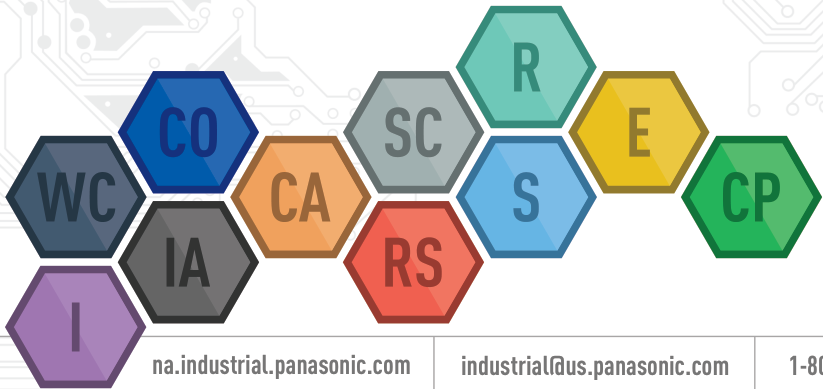
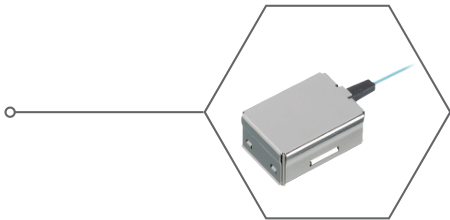
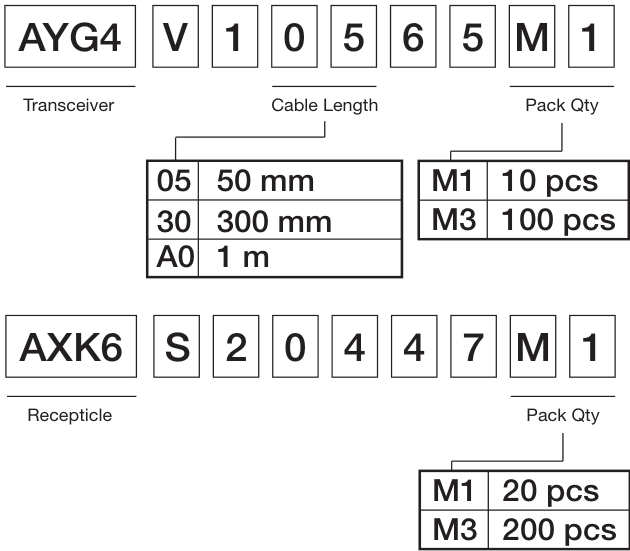
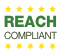
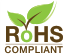
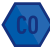
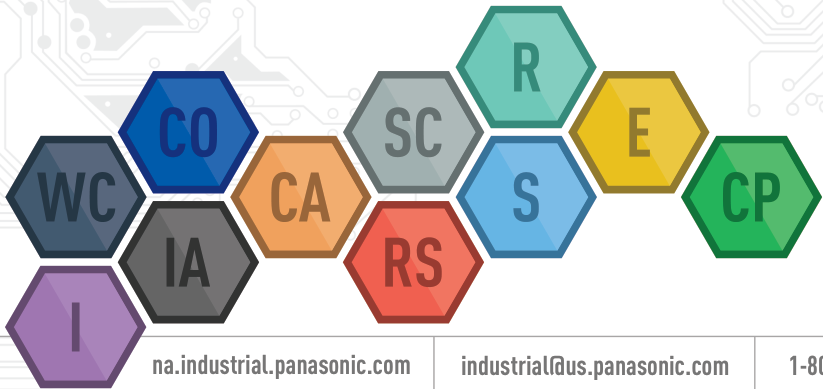
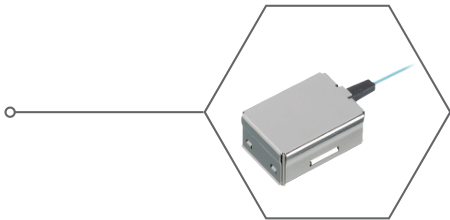
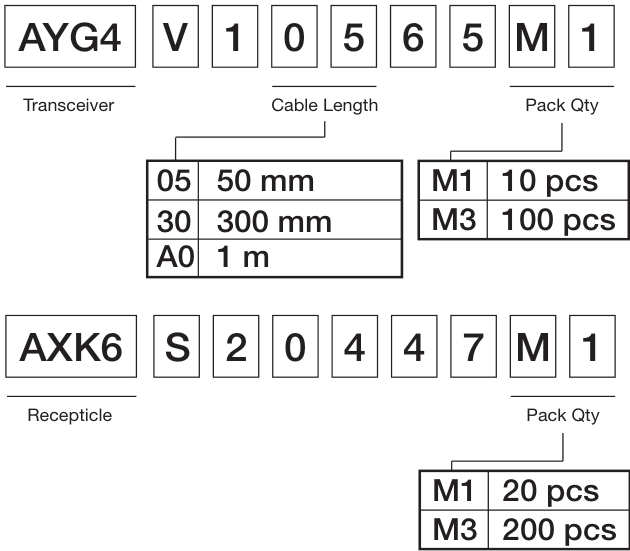
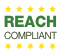
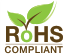
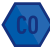

In [5]:
all_records[0]

In [7]:
for record in all_records:
    if "installation_guides" in record["file_path"]:
        record["category"] = "installation_guides"
    elif "product_catalogs" in record["file_path"]:
        record["category"] = "product_catalogs"
    elif "technical_guides" in record["file_path"]:
        record["category"] = "technical_guides"


In [5]:
all_records[0]

{'page_no': 0,
 'input_height': 2352,
 'input_width': 1652,
 'layout_info_path': '/home/parsa/panasonic/ocr_output/category/product_catalogs/pdf_file_7559/pdf_file_7559_page_0.json',
 'layout_image_path': '/home/parsa/panasonic/ocr_output/category/product_catalogs/pdf_file_7559/pdf_file_7559_page_0.jpg',
 'md_content_path': '/home/parsa/panasonic/ocr_output/category/product_catalogs/pdf_file_7559/pdf_file_7559_page_0.md',
 'filtered': True,
 'file_path': '/home/parsa/panasonic/pdf/category/product_catalogs/pdf_file_7559.pdf',
 'md_content': 'ERTJ1VR683J R-T Characteristics\n\n(for reference)\n\n$$R_{25} = 68 \\text{ kohm} \\quad \\text{+/-5\\%}$$\n\n$$B_{25/50} = 4250 \\text{ K} \\quad \\text{+/-2\\%}$$'}

In [6]:
ds = Dataset.from_list(all_records)
ds.save_to_disk("./hf-dataset/panasonic-v0.0/")

Saving the dataset (2/2 shards): 100%|██████████| 7525/7525 [00:00<00:00, 27336.09 examples/s]
